Lire data sur le fichier csv

In [163]:
import pandas as pd
df=pd.read_csv(r'C:\Users\saido\Pycharm\Simplon\Brief 1\appartements-data-db-6872f0ba853ec096170787.csv')
print(df.head(3))

                                               title         price  \
0       CMN-MA-1752 - Appartement à vendre à Palmier  2 000 000 DH   
1  66370-Vente Appt à Casablanca Hay Hassani de 1...  1 195 000 DH   
2           Appartement à vendre 81 m² à Dar Bouazza  1 350 000 DH   

     city_name  salon  nb_rooms  nb_baths  surface_area  \
0   Casablanca    NaN       2.0       2.0         168.0   
1   Casablanca    NaN       2.0       2.0          98.0   
2  Dar Bouazza    1.0       2.0       2.0          81.0   

                                           equipment  \
0                  Ascenseur/Balcon/Parking/Terrasse   
1  Ascenseur/Balcon/Chauffage/Climatisation/Cuisi...   
2  Ascenseur/Balcon/Chauffage/Climatisation/Conci...   

                                                link  
0  https://www.avito.ma/fr/palmier/appartements/C...  
1  https://www.avito.ma/fr/hay_hassani/appartemen...  
2  https://www.avito.ma/fr/dar_bouazza/appartemen...  


Aperçu des données

In [164]:
print('la taille du dataframe est de :', df.shape)
print('la description des données est :', df.describe())
print('les types de données sont :', df.dtypes)
print('les colonnes du dataframe sont :', df.columns)
print('le nombre des valeurs Nan',df.isnull().sum())

la taille du dataframe est de : (1773, 9)
la description des données est :              salon     nb_rooms     nb_baths   surface_area
count  1620.000000  1490.000000  1480.000000    1742.000000
mean      1.267284     2.379195     2.307432     174.933410
std       0.557539     0.667159     7.629128    2969.500693
min       0.000000     1.000000     0.000000       1.000000
25%       1.000000     2.000000     1.000000      71.000000
50%       1.000000     2.000000     2.000000      89.000000
75%       1.000000     3.000000     2.000000     114.750000
max       8.000000     7.000000   134.000000  123456.000000
les types de données sont : title            object
price            object
city_name        object
salon           float64
nb_rooms        float64
nb_baths        float64
surface_area    float64
equipment        object
link             object
dtype: object
les colonnes du dataframe sont : Index(['title', 'price', 'city_name', 'salon', 'nb_rooms', 'nb_baths',
       'surface_area', 

Détecter les valeurs manquantes

In [165]:
df["price"] = df["price"].str.replace(r"[^\d]", "", regex=True).astype(float)
print('type de price est :', df['price'].dtypes)
print('le nombre des valeurs Nan',df.isnull().sum())

type de price est : float64
le nombre des valeurs Nan title             1
price           283
city_name         1
salon           153
nb_rooms        283
nb_baths        293
surface_area     31
equipment       371
link              0
dtype: int64


Étudier la distribution des variables (histogrammes)

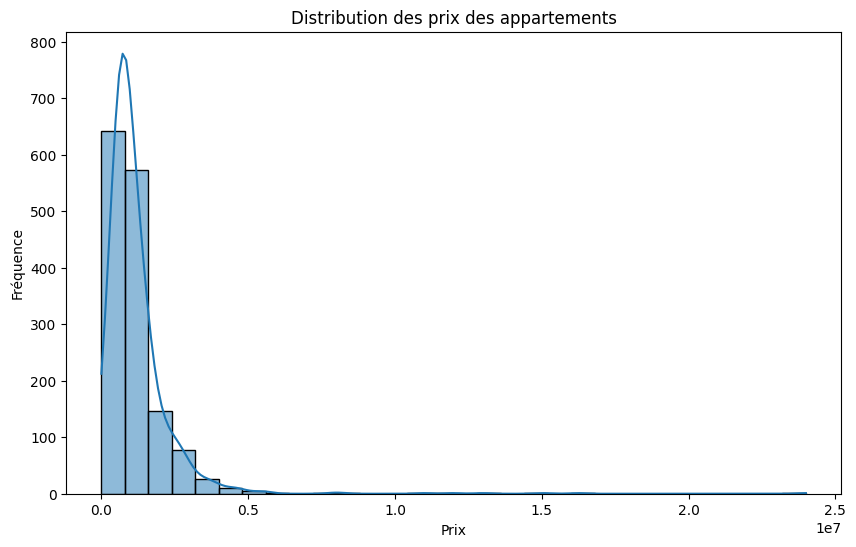

In [166]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=30, kde=True)
plt.title('Distribution des prix des appartements')
plt.xlabel('Prix')
plt.ylabel('Fréquence')
plt.show()

In [167]:
print('la description des données est :')
df.describe()

la description des données est :


,price,salon,nb_rooms,nb_baths,surface_area
count,1.490000e+03,1620.000000,1490.000000,1480.000000,1742.000000
mean,1.175197e+06,1.267284,2.379195,2.307432,174.933410
std,1.267979e+06,0.557539,0.667159,7.629128,2969.500693
min,3.500000e+01,0.000000,1.000000,0.000000,1.000000
25%,5.900000e+05,1.000000,2.000000,1.000000,71.000000
50%,8.800000e+05,1.000000,2.000000,2.000000,89.000000
75%,1.400000e+06,1.000000,3.000000,2.000000,114.750000
max,2.400000e+07,8.000000,7.000000,134.000000,123456.000000


In [170]:
df.head()
#modifier les valeurs Nan
df.fillna({
    "price": df["price"].mean(),
}, inplace=True)
# Supprimer les doublons
df.drop_duplicates(inplace=True)
df.head()

,title,price,city_name,salon,nb_rooms,nb_baths,surface_area,equipment,link
0,CMN-MA-1752 - Appartement à vendre à Palmier,2000000.0,Casablanca,1.0,2.0,2.0,168.0,Ascenseur/Balcon/Parking/Terrasse,https://www.avito.ma/fr/palmier/appartements/C...
1,66370-Vente Appt à Casablanca Hay Hassani de 1...,1195000.0,Casablanca,1.0,2.0,2.0,98.0,Ascenseur/Balcon/Chauffage/Climatisation/Cuisi...,https://www.avito.ma/fr/hay_hassani/appartemen...
2,Appartement à vendre 81 m² à Dar Bouazza,1350000.0,Dar Bouazza,1.0,2.0,2.0,81.0,Ascenseur/Balcon/Chauffage/Climatisation/Conci...,https://www.avito.ma/fr/dar_bouazza/appartemen...
3,63860-Vente Appt à Casablanca Quartier Bd Med ...,900000.0,Casablanca,1.0,1.0,1.0,56.0,Ascenseur/Chauffage/Climatisation/Cuisine Équi...,https://www.avito.ma/fr/centre_ville/apparteme...
4,Appartement à Rabat Agdal,3100000.0,Rabat,2.0,3.0,2.0,200.0,Ascenseur/Balcon/Concierge/Parking/Sécurité,https://www.avito.ma/fr/agdal/appartements/App...


In [193]:
df['salon'].dtypes
print('type de salon est :', df['salon'].dtypes)
df['salon']=df["salon"].astype(int)
print('le nombre des valeurs Nan',df['salon'].isnull().sum())
print('type de salon est :', df['salon'].dtypes)
print(df)

type de salon est : int64
le nombre des valeurs Nan 0
type de salon est : int64
                                                  title      price  \
1     66370-Vente Appt à Casablanca Hay Hassani de 1...  1195000.0   
2              Appartement à vendre 81 m² à Dar Bouazza  1350000.0   
3     63860-Vente Appt à Casablanca Quartier Bd Med ...   900000.0   
6                Appartement à vendre 98 m² à Marrakech   760000.0   
7     50620-Vente Appt à Casablanca Hay Mohammadi de 73   790000.0   
...                                                 ...        ...   
1763    Des Appartement à vendre 89 m² à Temara fawarat   985000.0   
1764                                   appartement neuf   730000.0   
1765                Appartement à vendre 60 m² à Meknès   300000.0   
1766                               Appartement location     3500.0   
1767                          appartement 4 minutes tgv   700000.0   

        city_name  salon  nb_rooms  nb_baths  surface_area  \
1      Casablanca

Détecter les outliers

In [194]:
for col in df.select_dtypes(include=['int64', 'float64']).columns:  # sélectionne uniquement les colonnes numériques
    q1= df[col].quantile(0.25)
    q3= df[col].quantile(0.75)
    iqr = q3 - q1
    min= q1 - 1.5 * iqr
    max= q3 + 1.5 * iqr
    outliers = df[(df[col] < min) | (df[col] > max)]
    print("les columns avec des valeurs extrêmes sont :", col)
    print("les valeurs extrêmes sont :", outliers[col])

les columns avec des valeurs extrêmes sont : price
les valeurs extrêmes sont : 465     2100000.0
849     2050000.0
953     2040000.0
1046    2100000.0
Name: price, dtype: float64
les columns avec des valeurs extrêmes sont : salon
les valeurs extrêmes sont : Series([], Name: salon, dtype: int64)
les columns avec des valeurs extrêmes sont : nb_rooms
les valeurs extrêmes sont : Series([], Name: nb_rooms, dtype: float64)
les columns avec des valeurs extrêmes sont : nb_baths
les valeurs extrêmes sont : Series([], Name: nb_baths, dtype: float64)
les columns avec des valeurs extrêmes sont : surface_area
les valeurs extrêmes sont : Series([], Name: surface_area, dtype: float64)


Supprimer les outliers

In [195]:
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    min_val = q1 - 1.5 * iqr
    max_val = q3 + 1.5 * iqr

    # Mise à jour du DataFrame en filtrant les lignes valides
    df = df[(df[col] >= min_val) & (df[col] <= max_val)]

print("Suppression des outliers réussie !")
print(df.head())


Suppression des outliers réussie !
                                               title      price    city_name  \
1  66370-Vente Appt à Casablanca Hay Hassani de 1...  1195000.0   Casablanca   
2           Appartement à vendre 81 m² à Dar Bouazza  1350000.0  Dar Bouazza   
3  63860-Vente Appt à Casablanca Quartier Bd Med ...   900000.0   Casablanca   
6             Appartement à vendre 98 m² à Marrakech   760000.0    Marrakech   
7  50620-Vente Appt à Casablanca Hay Mohammadi de 73   790000.0   Casablanca   

   salon  nb_rooms  nb_baths  surface_area  \
1      1       2.0       2.0          98.0   
2      1       2.0       2.0          81.0   
3      1       1.0       1.0          56.0   
6      1       3.0       3.0          98.0   
7      1       3.0       2.0          73.0   

                                           equipment  \
1  Ascenseur/Balcon/Chauffage/Climatisation/Cuisi...   
2  Ascenseur/Balcon/Chauffage/Climatisation/Conci...   
3  Ascenseur/Chauffage/Climatisation/Cu

verifier la supprition des outliers

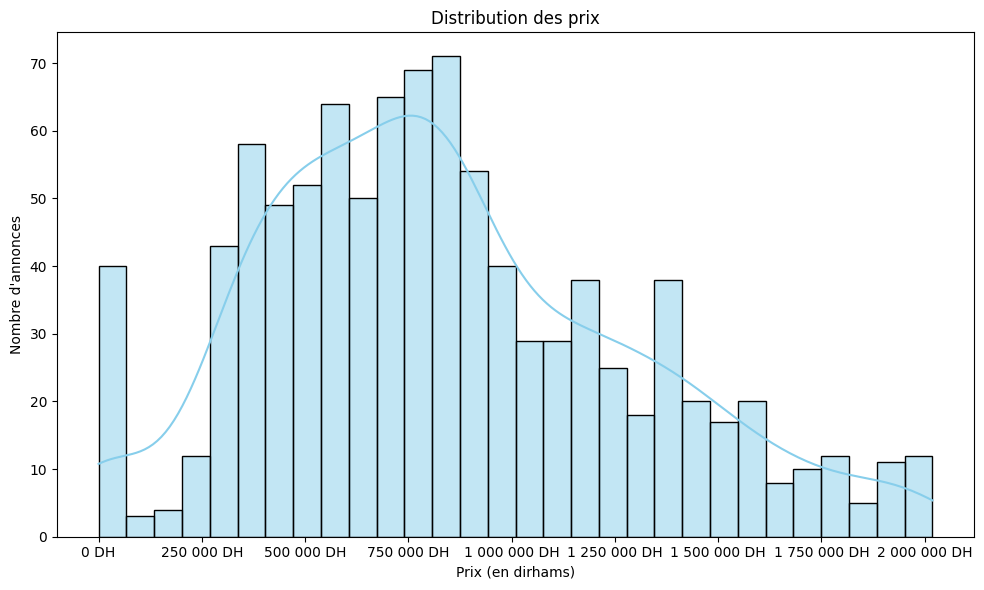

In [196]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

plt.figure(figsize=(10, 6))
sns.histplot(df["price"].dropna(), kde=True, bins=30, color="skyblue")
plt.title("Distribution des prix")
plt.xlabel("Prix (en dirhams)")
plt.ylabel("Nombre d'annonces")
plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", " ") + " DH"))
plt.tight_layout()
plt.show()


Quelle est la corrélation entre le prix et les autres variables ?

Corrélation avec la variable 'price' :
price           1.000000
surface_area    0.510755
nb_baths        0.280011
nb_rooms        0.176541
salon                NaN
Name: price, dtype: float64


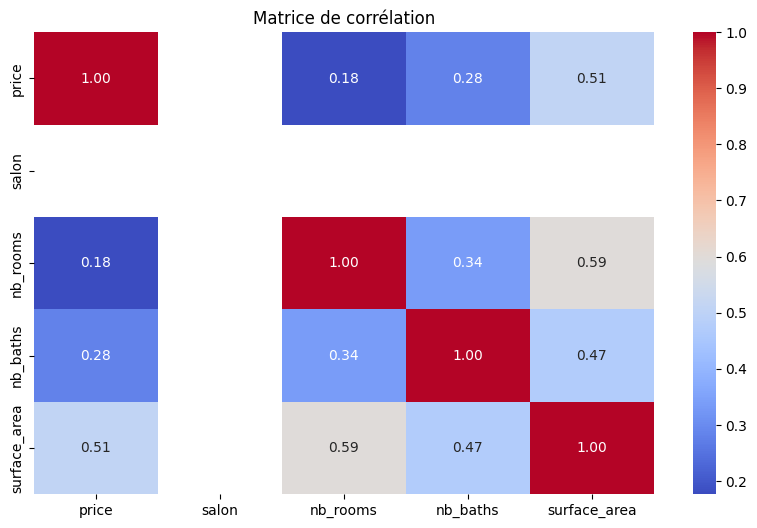

In [197]:
correlation_matrix = df.corr(numeric_only=True)
# Affichage de la corrélation entre "price" et les autres colonnes
print("Corrélation avec la variable 'price' :")
print(correlation_matrix["price"].sort_values(ascending=False))
# Visualisation avec une heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de corrélation")
plt.show()


la solution de valeur Nan de salon

In [198]:
print(df['salon'].unique())
print(df['salon'].dtype)
print(df['salon'].isna().sum())
print(df['salon'].value_counts())
df['salon'] = df['salon'].fillna(df['salon'].mean()).astype(int)
print("Valeurs NaN dans 'salon' remplacées par la moyenne et converties en entier.")

[1]
int64
0
salon
1    966
Name: count, dtype: int64
Valeurs NaN dans 'salon' remplacées par la moyenne et converties en entier.


Corrélation avec la variable 'price' :
price           1.000000
surface_area    0.510755
nb_baths        0.280011
nb_rooms        0.176541
salon                NaN
Name: price, dtype: float64


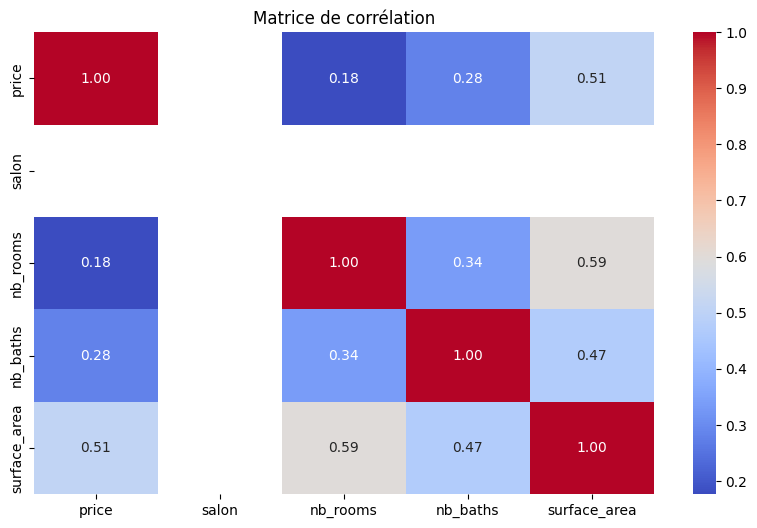

In [199]:
correlation_matrix = df.corr(numeric_only=True)
# Affichage de la corrélation entre "price" et les autres colonnes
print("Corrélation avec la variable 'price' :")
print(correlation_matrix["price"].sort_values(ascending=False))
# Visualisation avec une heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de corrélation")
plt.show()


autre graphe

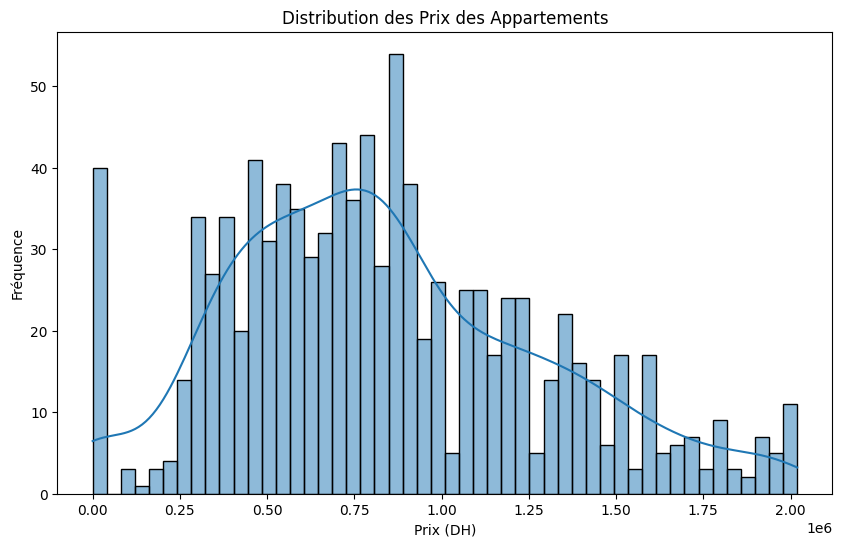

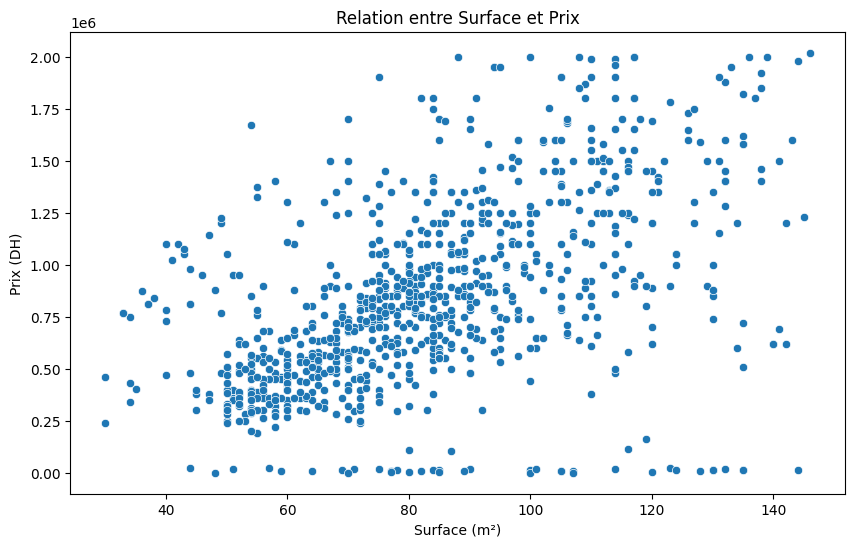

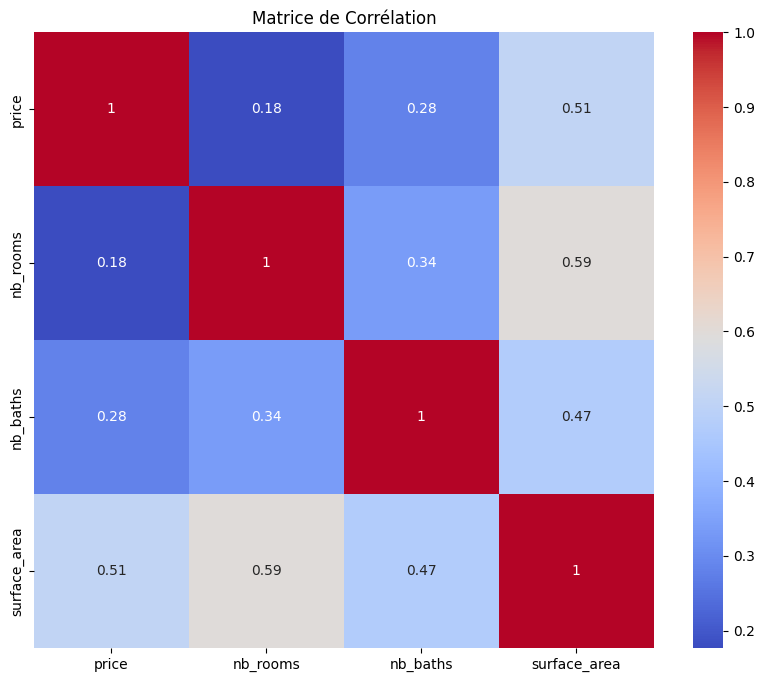

In [200]:
# Distribution des prix
plt.figure(figsize=(10,6))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution des Prix des Appartements')
plt.xlabel('Prix (DH)')
plt.ylabel('Fréquence')
plt.show()

# Relation surface/prix
plt.figure(figsize=(10,6))
sns.scatterplot(x='surface_area', y='price', data=df)
plt.title('Relation entre Surface et Prix')
plt.xlabel('Surface (m²)')
plt.ylabel('Prix (DH)')
plt.show()

# Matrice de corrélation
corr_matrix = df.select_dtypes(include=['float64']).corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Matrice de Corrélation')
plt.show()

 Détection des valeurs manquantes

In [201]:
# Pour voir combien de valeurs manquantes par colonne
print(df.isnull().sum())

# Pourcentage de valeurs manquantes
print((df.isnull().sum() / len(df)) * 100)


title             0
price             0
city_name         0
salon             0
nb_rooms          0
nb_baths          0
surface_area      0
equipment       201
link              0
dtype: int64
title            0.000000
price            0.000000
city_name        0.000000
salon            0.000000
nb_rooms         0.000000
nb_baths         0.000000
surface_area     0.000000
equipment       20.807453
link             0.000000
dtype: float64


Gestion des équipements

In [202]:
df.head()

,title,price,city_name,salon,nb_rooms,nb_baths,surface_area,equipment,link
1,66370-Vente Appt à Casablanca Hay Hassani de 1...,1195000.0,Casablanca,1,2.0,2.0,98.0,Ascenseur/Balcon/Chauffage/Climatisation/Cuisi...,https://www.avito.ma/fr/hay_hassani/appartemen...
2,Appartement à vendre 81 m² à Dar Bouazza,1350000.0,Dar Bouazza,1,2.0,2.0,81.0,Ascenseur/Balcon/Chauffage/Climatisation/Conci...,https://www.avito.ma/fr/dar_bouazza/appartemen...
3,63860-Vente Appt à Casablanca Quartier Bd Med ...,900000.0,Casablanca,1,1.0,1.0,56.0,Ascenseur/Chauffage/Climatisation/Cuisine Équi...,https://www.avito.ma/fr/centre_ville/apparteme...
6,Appartement à vendre 98 m² à Marrakech,760000.0,Marrakech,1,3.0,3.0,98.0,Ascenseur/Balcon/Concierge/Cuisine Équipée/Par...,https://www.avito.ma/fr/akioud/appartements/Ap...
7,50620-Vente Appt à Casablanca Hay Mohammadi de 73,790000.0,Casablanca,1,3.0,2.0,73.0,Cuisine Équipée,https://www.avito.ma/fr/hay_mohammadi/appartem...


In [203]:
# Création de colonnes booléennes pour chaque équipement
equipment_dummies = df['equipment'].str.get_dummies('/')
df = pd.concat([df, equipment_dummies], axis=1)

# Suppression des colonnes inutiles
df.drop(['equipment', 'link', 'title'], axis=1, inplace=True)


In [204]:
df.head()

,price,city_name,salon,nb_rooms,nb_baths,surface_area,Ascenseur,Balcon,Chauffage,Climatisation,Concierge,Cuisine Équipée,Duplex,Meublé,Parking,Sécurité,Terrasse
1,1195000.0,Casablanca,1,2.0,2.0,98.0,1,1,1,1,0,1,0,0,1,0,0
2,1350000.0,Dar Bouazza,1,2.0,2.0,81.0,1,1,1,1,1,1,1,0,1,1,1
3,900000.0,Casablanca,1,1.0,1.0,56.0,1,0,1,1,0,1,0,1,1,1,1
6,760000.0,Marrakech,1,3.0,3.0,98.0,1,1,0,0,1,1,0,0,1,1,0
7,790000.0,Casablanca,1,3.0,2.0,73.0,0,0,0,0,0,1,0,0,0,0,0


renomer les ville

In [ ]:
# Uniformisation des noms de villes
city_mapping = {
    'Casablanca': 'الدار البيضاء',
    'Kénitra': 'القنيطرة',
    'Agadir': 'أكادير',
    'Mohammedia': 'المحمدية',
    'Tanger': 'طنجة'
}
df['city_name'] = df['city_name'].replace(city_mapping)
df['city_name'] = df['city_name'].fillna('Unknown')
df.head()

,price,city_name,salon,nb_rooms,nb_baths,surface_area,Ascenseur,Balcon,Chauffage,Climatisation,Concierge,Cuisine Équipée,Duplex,Meublé,Parking,Sécurité,Terrasse
1,1195000.0,الدار البيضاء,1,2.0,2.0,98.0,1,1,1,1,0,1,0,0,1,0,0
2,1350000.0,Dar Bouazza,1,2.0,2.0,81.0,1,1,1,1,1,1,1,0,1,1,1
3,900000.0,الدار البيضاء,1,1.0,1.0,56.0,1,0,1,1,0,1,0,1,1,1,1
6,760000.0,Marrakech,1,3.0,3.0,98.0,1,1,0,0,1,1,0,0,1,1,0
7,790000.0,الدار البيضاء,1,3.0,2.0,73.0,0,0,0,0,0,1,0,0,0,0,0


Identifier les variables catégorielles

In [154]:
colonnes_categor = df.select_dtypes(include=['object', 'category']).columns
print("Colonnes catégorielles :", colonnes_categor.tolist())

Colonnes catégorielles : []


Encodage par étiquettes (Label Encoding)

In [150]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['city_name'] = le.fit_transform(df['city_name']) 
df

,price,city_name,salon,nb_rooms,nb_baths,surface_area,Ascenseur,Balcon,Chauffage,Climatisation,Concierge,Cuisine Équipée,Duplex,Meublé,Parking,Sécurité,Terrasse
1,1195000.0,11,1,2.0,2.0,98.0,1,1,1,1,0,1,0,0,1,0,0
2,1350000.0,13,1,2.0,2.0,81.0,1,1,1,1,1,1,1,0,1,1,1
3,900000.0,11,1,1.0,1.0,56.0,1,0,1,1,0,1,0,1,1,1,1
6,760000.0,27,1,3.0,3.0,98.0,1,1,0,0,1,1,0,0,1,1,0
7,790000.0,11,1,3.0,2.0,73.0,0,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1763,985000.0,49,1,3.0,1.0,89.0,1,1,0,0,1,1,0,0,1,0,0
1764,730000.0,47,1,2.0,1.0,73.0,1,1,0,0,0,0,0,0,0,0,0
1765,300000.0,31,1,3.0,1.0,60.0,1,0,0,0,1,0,0,0,1,1,0
1766,3500.0,52,1,2.0,2.0,85.0,1,1,0,0,0,1,0,1,0,1,0


[11 13 27  4  7 26 32 35 46 38 23  0 49 47  8 31 17 22 18 53 52 37 28 21
  9 45 10 14 43 34  3 36 54 24 12 15 44 51  1  5 19 20 33 50  6 30  2 29
 25 39 16 40 41 42 48]
